In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error

In [128]:
df = pd.read_csv(r"C:\Users\HP\Desktop\AI_project\week-06-regression-and-classification-ML\datasets\laptop_prices.csv")

In [129]:
df.head()

,ram_gb,storage_gb,screen_size,weight_kg,cpu_score,gpu_score,age_years,price
0,16,256,12.0,1.80,5381,3209,3,912.0
1,32,1024,12.5,1.38,12751,13736,5,1990.0
2,16,256,14.8,2.06,3634,7953,5,1094.0
3,8,1024,16.9,2.41,8392,2067,2,1084.0
4,8,1024,14.0,2.31,22301,19385,1,2068.0


In [130]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price          1.000000
ram_gb         0.778689
gpu_score      0.432267
cpu_score      0.230264
storage_gb     0.154518
screen_size    0.153477
weight_kg      0.040739
age_years     -0.253912
Name: price, dtype: float64

In [131]:
features = ['ram_gb','gpu_score','cpu_score','storage_gb']

In [132]:
x = df[features]

In [133]:
y = df['price']

In [134]:
x.shape

(1200, 4)

In [135]:
y.shape

(1200,)

In [136]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size= 0.2 ,random_state=42)

In [137]:
print("x_train" , x_train.shape)
print("x_test" , x_test.shape)
print("y_train" , y_train.shape)
print("y_test" , x_test.shape)

x_train (960, 4)
x_test (240, 4)
y_train (960,)
y_test (240, 4)


In [138]:
model = LinearRegression()
model.fit(x_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.05, 0.03, 0.02, 0.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['ram_gb','gpu_score','cpu_score','storage_gb']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,506.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [139]:
prediction = model.predict(x_test)

In [140]:
r2= r2_score(y_test,prediction)
rmse = np.sqrt(mean_squared_error(y_test,prediction))
r2

0.8180566980928755

In [141]:
rmse

np.float64(175.54107157938046)

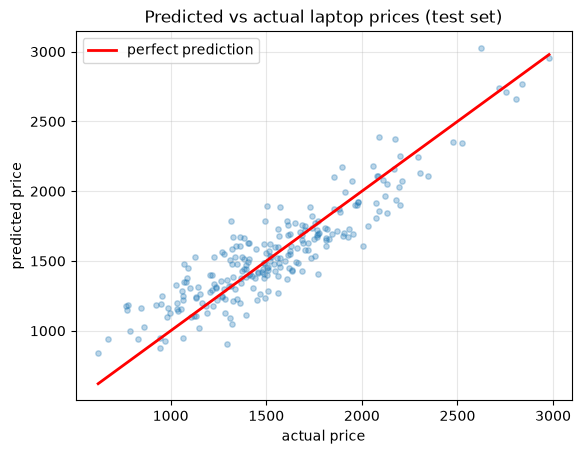

In [142]:
plt.scatter(y_test, prediction, alpha=0.3, s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="perfect prediction")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("Predicted vs actual laptop prices (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [143]:
x2 = np.c_(x , x**2)

TypeError: 'CClass' object is not callable